In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("clustering.csv")

print("First 5 rows of the dataset:")
print(df.head())

In [ ]:

data = df
print("\nLast 5 records:")
print(data.tail())

print("\nDataset shape:")
print(data.shape)


In [ ]:
# Select required features

X = data[["LoanAmount", "ApplicantIncome"]]

X.head()

In [ ]:
# Visualize data points

plt.scatter(
    X["ApplicantIncome"],
    X["LoanAmount"],
    c="red"
)

plt.xlabel("Annual Income")
plt.ylabel("Loan Amount (In Thousands)")
plt.title("Loan Amount vs Applicant Income")

plt.show()

In [ ]:
# STEP 4: CHOOSE NUMBER OF CLUSTERS


K = 3

print("\nNumber of clusters:", K)


# Select random observations as initial centroids

Centroids = X.sample(n=K)

print(Centroids)

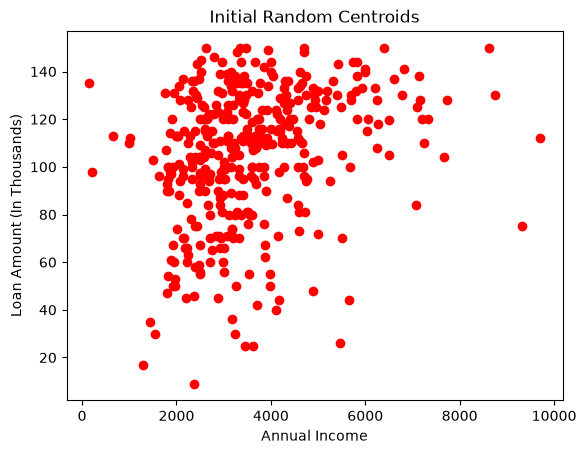

In [ ]:
plt.scatter(
    X["ApplicantIncome"],
    X["LoanAmount"],
    c="Black"
)

plt.scatter(
    Centroids["ApplicantIncome"],
    Centroids["LoanAmount"],
    c="red"
)

plt.xlabel("Annual Income")
plt.ylabel("Loan Amount (In Thousands)")
plt.title("Initial Random Centroids")

plt.show()

In [18]:
# Implement K-Means algorithm

diff = 1
j = 0

while diff != 0:

    XD = X.copy()

    i = 1

    # Calculate distance from every centroid
    for index1, row_c in Centroids.iterrows():

        ED = []

        for index2, row_d in XD.iterrows():

            d1 = (
                row_c["ApplicantIncome"]
                - row_d["ApplicantIncome"]
            ) ** 2

            d2 = (
                row_c["LoanAmount"]
                - row_d["LoanAmount"]
            ) ** 2

            d = np.sqrt(d1 + d2)

            ED.append(d)

        X[i] = ED

        i = i + 1

    # Assign each point to nearest centroid

    C = []

    for index, row in X.iterrows():

        min_dist = row[1]
        pos = 1

        for i in range(K):

            if row[i + 1] < min_dist:

                min_dist = row[i + 1]
                pos = i + 1

        C.append(pos)

    X["Cluster"] = C

    # Calculate new centroids

    Centroids_new = X.groupby(
        ["Cluster"]
    ).mean()[["LoanAmount", "ApplicantIncome"]]

    # Check convergence

    if j == 0:

        diff = 1
        j = j + 1

    else:

        diff = (
            Centroids_new["LoanAmount"]
            - Centroids["LoanAmount"]
        ).sum() + (
            Centroids_new["ApplicantIncome"]
            - Centroids["ApplicantIncome"]
        ).sum()

        print(diff)

    # Update centroids

    Centroids = X.groupby(
        ["Cluster"]
    ).mean()[["LoanAmount", "ApplicantIncome"]]

    print(Centroids)

         LoanAmount  ApplicantIncome
Cluster                             
1         97.472527      2497.972527
2        119.488372      6512.767442
3        109.756410      4033.596154
0.0
         LoanAmount  ApplicantIncome
Cluster                             
1         97.472527      2497.972527
2        119.488372      6512.767442
3        109.756410      4033.596154


In [ ]:
d = np.sqrt(d1 + d2)
X[i] = ED
print("\nFinal Centroids:")
print(Centroids)

In [ ]:
if row[i + 1] < min_dist:
    X["Cluster"] = C
    Centroids_new = X.groupby(
    ["Cluster"]
).mean()[["LoanAmount", "ApplicantIncome"]]
print("\nFinal Centroids:")
print(Centroids_new)